# EDA 16.2: Train-Test Horizon Awareness

This notebook analyzes train-test horizon awareness for daily Revenue forecasting across the fixed test horizon from `2023-01-01` to `2024-07-01`, with emphasis on lag and rolling feature availability, recursive dependency risk, and practical strategy choice.

## 1. Setup and File Discovery

Locate the primary Revenue source and optional supporting files under the current working directory. Missing files produce warnings and the notebook continues where possible.

In [1]:
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings("default")
pd.set_option("display.max_columns", 240)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

ROOT = Path.cwd()
FILES = [
    "sales.csv",
    "sample_submission.csv",
    "orders.csv",
    "order_items.csv",
    "web_traffic.csv",
    "promotions.csv",
    "inventory.csv",
]

TEST_START = pd.Timestamp("2023-01-01")
TEST_END = pd.Timestamp("2024-07-01")

def normalize_name(name):
    return re.sub(r"[^a-z0-9]+", "", str(name).strip().lower())

def discover_csvs(root):
    found = {}
    for path in root.rglob("*.csv"):
        key = path.name.lower()
        if key not in found:
            found[key] = path
    return found

csv_files = discover_csvs(ROOT)
selected_paths = {name: csv_files.get(name.lower()) for name in FILES}

display(pd.DataFrame([
    {"file": name, "found": path is not None, "path": str(path) if path else None}
    for name, path in selected_paths.items()
]))

,file,found,path
0,sales.csv,True,D:\Code\Datathon 2026\datathon-2026-round-1\sa...
1,sample_submission.csv,True,D:\Code\Datathon 2026\datathon-2026-round-1\sa...
2,orders.csv,True,D:\Code\Datathon 2026\datathon-2026-round-1\or...
3,order_items.csv,True,D:\Code\Datathon 2026\datathon-2026-round-1\or...
4,web_traffic.csv,True,D:\Code\Datathon 2026\datathon-2026-round-1\we...
5,promotions.csv,True,D:\Code\Datathon 2026\datathon-2026-round-1\pr...
6,inventory.csv,True,D:\Code\Datathon 2026\datathon-2026-round-1\in...


## 2. Load Revenue and Optional Files

Load `sales.csv` when available. If needed, reconstruct Revenue from `orders.csv` and `order_items.csv`. Optional files are loaded only to classify future feature availability.

In [2]:
def load_csv_safe(path):
    if path is None:
        return None
    try:
        return pd.read_csv(path, low_memory=False)
    except Exception as exc:
        warnings.warn(f"Failed to load {path}: {exc}")
        return None

sales = load_csv_safe(selected_paths["sales.csv"])
sample_submission = load_csv_safe(selected_paths["sample_submission.csv"])
orders = load_csv_safe(selected_paths["orders.csv"])
order_items = load_csv_safe(selected_paths["order_items.csv"])
web_traffic = load_csv_safe(selected_paths["web_traffic.csv"])
promotions = load_csv_safe(selected_paths["promotions.csv"])
inventory = load_csv_safe(selected_paths["inventory.csv"])

def normalized_map(columns):
    return {normalize_name(c): c for c in columns}

def find_column(columns, candidates, contains=False):
    nmap = normalized_map(columns)
    normalized_candidates = [normalize_name(c) for c in candidates]
    for cand in normalized_candidates:
        if cand in nmap:
            return nmap[cand]
    if contains:
        for cand in normalized_candidates:
            for ncol, raw in nmap.items():
                if cand in ncol:
                    return raw
    return None

sales_cols = {}
if sales is not None:
    sales_cols = {
        "date": find_column(sales.columns, ["date", "sales_date", "order_date"], contains=True),
        "revenue": find_column(sales.columns, ["revenue", "sales_amount", "total_revenue", "amount"], contains=True),
    }

submission_cols = {}
if sample_submission is not None:
    submission_cols = {
        "date": find_column(sample_submission.columns, ["date", "sales_date", "order_date"], contains=True),
    }

orders_cols = {}
if orders is not None:
    orders_cols = {
        "order_id": find_column(orders.columns, ["order_id"]),
        "order_date": find_column(orders.columns, ["order_date", "date"], contains=True),
        "order_status": find_column(orders.columns, ["order_status", "status"], contains=True),
    }

item_cols = {}
if order_items is not None:
    item_cols = {
        "order_id": find_column(order_items.columns, ["order_id"]),
        "quantity": find_column(order_items.columns, ["quantity", "qty", "units"], contains=True),
        "unit_price": find_column(order_items.columns, ["unit_price", "price", "selling_price"], contains=True),
        "discount_amount": find_column(order_items.columns, ["discount_amount", "discount"], contains=True),
        "item_revenue": find_column(order_items.columns, ["item_total", "line_total", "revenue", "sales_amount", "net_sales"], contains=True),
    }

traffic_cols = {}
if web_traffic is not None:
    traffic_cols = {
        "date": find_column(web_traffic.columns, ["date", "traffic_date"], contains=True),
        "sessions": find_column(web_traffic.columns, ["sessions"], contains=True),
    }

promo_cols = {}
if promotions is not None:
    promo_cols = {
        "start_date": find_column(promotions.columns, ["start_date", "promotion_start_date"], contains=True),
        "end_date": find_column(promotions.columns, ["end_date", "promotion_end_date"], contains=True),
    }

inventory_cols = {}
if inventory is not None:
    inventory_cols = {
        "snapshot_date": find_column(inventory.columns, ["snapshot_date", "date", "inventory_date"], contains=True),
    }

display(pd.DataFrame({
    "sales": pd.Series(sales_cols),
    "sample_submission": pd.Series(submission_cols),
    "orders": pd.Series(orders_cols),
    "order_items": pd.Series(item_cols),
    "web_traffic": pd.Series(traffic_cols),
    "promotions": pd.Series(promo_cols),
    "inventory": pd.Series(inventory_cols),
}))

,sales,sample_submission,orders,order_items,web_traffic,promotions,inventory
date,Date,Date,NaN,NaN,date,NaN,NaN
discount_amount,NaN,NaN,NaN,discount_amount,NaN,NaN,NaN
end_date,NaN,NaN,NaN,NaN,NaN,end_date,NaN
item_revenue,NaN,NaN,NaN,None,NaN,NaN,NaN
order_date,NaN,NaN,order_date,NaN,NaN,NaN,NaN
order_id,NaN,NaN,order_id,order_id,NaN,NaN,NaN
order_status,NaN,NaN,order_status,NaN,NaN,NaN,NaN
quantity,NaN,NaN,NaN,quantity,NaN,NaN,NaN
revenue,Revenue,NaN,NaN,NaN,NaN,NaN,NaN
sessions,NaN,NaN,NaN,NaN,sessions,NaN,NaN


## 3. Prepare Daily Revenue Series

Prepare the daily Revenue history from the best available source. This notebook never uses actual test-period Revenue to build test features.

In [3]:
revenue_source = None
daily_revenue = pd.DataFrame(columns=["date", "Revenue"])

if sales is not None and sales_cols.get("date") and sales_cols.get("revenue"):
    sales_tmp = sales.copy()
    sales_tmp["date"] = pd.to_datetime(sales_tmp[sales_cols["date"]], errors="coerce")
    sales_tmp["Revenue"] = pd.to_numeric(sales_tmp[sales_cols["revenue"]], errors="coerce")
    daily_revenue = (
        sales_tmp.dropna(subset=["date"])
        .groupby("date", as_index=False)["Revenue"]
        .sum()
        .sort_values("date")
    )
    revenue_source = "sales.csv"
elif (
    orders is not None
    and order_items is not None
    and orders_cols.get("order_id")
    and orders_cols.get("order_date")
    and item_cols.get("order_id")
):
    orders_tmp = orders.copy()
    orders_tmp["order_id_std"] = orders_tmp[orders_cols["order_id"]]
    orders_tmp["order_date_std"] = pd.to_datetime(orders_tmp[orders_cols["order_date"]], errors="coerce")
    items_tmp = order_items.copy()
    items_tmp["order_id_std"] = items_tmp[item_cols["order_id"]]
    qty = pd.to_numeric(items_tmp[item_cols["quantity"]], errors="coerce") if item_cols.get("quantity") else np.nan
    price = pd.to_numeric(items_tmp[item_cols["unit_price"]], errors="coerce") if item_cols.get("unit_price") else np.nan
    discount = pd.to_numeric(items_tmp[item_cols["discount_amount"]], errors="coerce").fillna(0) if item_cols.get("discount_amount") else 0
    if item_cols.get("item_revenue"):
        items_tmp["item_revenue_std"] = pd.to_numeric(items_tmp[item_cols["item_revenue"]], errors="coerce")
    else:
        items_tmp["item_revenue_std"] = qty * price
    order_rev = items_tmp.groupby("order_id_std", as_index=False)["item_revenue_std"].sum()
    order_rev = order_rev.merge(orders_tmp[["order_id_std", "order_date_std"]], on="order_id_std", how="left")
    daily_revenue = (
        order_rev.dropna(subset=["order_date_std"])
        .groupby("order_date_std", as_index=False)["item_revenue_std"]
        .sum()
        .rename(columns={"order_date_std": "date", "item_revenue_std": "Revenue"})
        .sort_values("date")
    )
    revenue_source = "orders.csv + order_items.csv"
else:
    warnings.warn("Revenue could not be identified or reconstructed. The notebook will continue with fixed-horizon analysis only.")

boundary_summary = pd.DataFrame()
submission_summary = pd.DataFrame()

if not daily_revenue.empty:
    daily_revenue = daily_revenue.sort_values("date").reset_index(drop=True)
    all_days = pd.date_range(daily_revenue["date"].min(), daily_revenue["date"].max(), freq="D")
    display(pd.DataFrame([{
        "revenue_source": revenue_source,
        "available_start": daily_revenue["date"].min(),
        "available_end": daily_revenue["date"].max(),
        "revenue_days": len(daily_revenue),
        "missing_dates": len(all_days.difference(daily_revenue["date"])),
        "duplicate_dates": int(daily_revenue["date"].duplicated().sum()),
        "zero_revenue_days": int(daily_revenue["Revenue"].eq(0).sum()),
        "negative_revenue_days": int(daily_revenue["Revenue"].lt(0).sum()),
    }]))
    display(daily_revenue.head(10))

if sample_submission is not None and submission_cols.get("date"):
    sub_dates = pd.to_datetime(sample_submission[submission_cols["date"]], errors="coerce").dropna().sort_values()
    submission_summary = pd.DataFrame([{
        "sample_submission_start": sub_dates.min(),
        "sample_submission_end": sub_dates.max(),
        "sample_submission_rows": len(sub_dates),
        "matches_fixed_test_start": sub_dates.min() == TEST_START,
        "matches_fixed_test_end": sub_dates.max() == TEST_END,
    }])
    display(submission_summary)

,revenue_source,available_start,available_end,revenue_days,missing_dates,duplicate_dates,zero_revenue_days,negative_revenue_days
0,sales.csv,2012-07-04,2022-12-31,3833,0,0,0,0


,date,Revenue
0,2012-07-04,"5,123,547.9400"
1,2012-07-05,"2,751,773.4500"
2,2012-07-06,"3,054,029.4200"
3,2012-07-07,"2,667,930.9400"
4,2012-07-08,"2,360,851.9000"
5,2012-07-09,"3,548,386.4600"
6,2012-07-10,"5,234,938.6200"
7,2012-07-11,"5,582,884.7800"
8,2012-07-12,"5,734,632.0200"
9,2012-07-13,"5,309,511.7100"


,sample_submission_start,sample_submission_end,sample_submission_rows,matches_fixed_test_start,matches_fixed_test_end
0,2023-01-01,2024-07-01,548,True,True


## 4. Test Horizon Calculation

Construct the fixed unseen test horizon from `2023-01-01` to `2024-07-01` and quantify the prediction span.

In [4]:
test_dates = pd.date_range(TEST_START, TEST_END, freq="D")
test_df = pd.DataFrame({"date": test_dates})
test_df["month"] = test_df["date"].dt.to_period("M").astype(str)
test_df["year"] = test_df["date"].dt.year

horizon_summary = pd.DataFrame([{
    "test_start": TEST_START,
    "test_end": TEST_END,
    "prediction_days": len(test_dates),
    "months_covered": test_df["month"].nunique(),
    "calendar_years_touched": test_df["year"].nunique(),
}])
display(horizon_summary)
display(pd.DataFrame({
    "first_10_test_dates": test_dates[:10].astype(str),
    "last_10_test_dates": test_dates[-10:].astype(str),
}))

,test_start,test_end,prediction_days,months_covered,calendar_years_touched
0,2023-01-01,2024-07-01,548,19,2


,first_10_test_dates,last_10_test_dates
0,2023-01-01,2024-06-22
1,2023-01-02,2024-06-23
2,2023-01-03,2024-06-24
3,2023-01-04,2024-06-25
4,2023-01-05,2024-06-26
5,2023-01-06,2024-06-27
6,2023-01-07,2024-06-28
7,2023-01-08,2024-06-29
8,2023-01-09,2024-06-30
9,2023-01-10,2024-07-01


## 5. Train-Test Boundary Check

Check whether known daily Revenue history ends cleanly at the boundary before the test horizon starts and whether there are gaps near that boundary.

,last_known_Revenue_date,expected_boundary_date,gap_days_before_test_start,trailing_30d_missing_dates,continuous_history_to_boundary
0,2022-12-31,2022-12-31,0,0,True


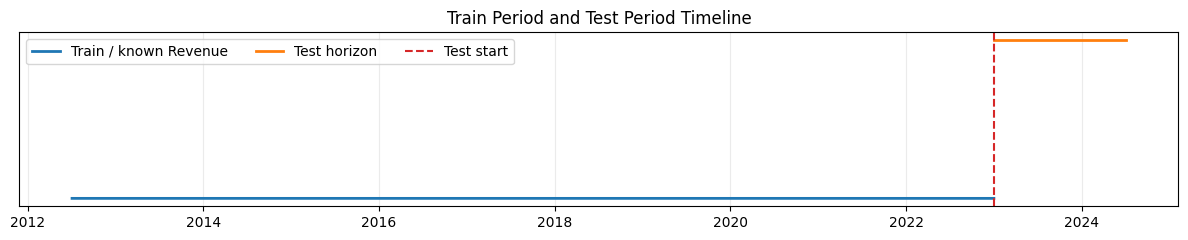

In [5]:
train_test_boundary = pd.DataFrame()
history_continuous_to_boundary = False

if not daily_revenue.empty:
    last_known_date = daily_revenue["date"].max()
    gap_days = (TEST_START - last_known_date).days - 1
    trailing_window = pd.date_range(last_known_date - pd.Timedelta(days=29), last_known_date, freq="D")
    trailing_missing = len(trailing_window.difference(pd.Index(daily_revenue["date"])))
    history_continuous_to_boundary = (last_known_date == pd.Timestamp("2022-12-31")) and trailing_missing == 0
    train_test_boundary = pd.DataFrame([{
        "last_known_Revenue_date": last_known_date,
        "expected_boundary_date": pd.Timestamp("2022-12-31"),
        "gap_days_before_test_start": gap_days,
        "trailing_30d_missing_dates": trailing_missing,
        "continuous_history_to_boundary": history_continuous_to_boundary,
    }])
    display(train_test_boundary)

    fig, ax = plt.subplots(figsize=(12, 2.5))
    ax.plot(daily_revenue["date"], np.ones(len(daily_revenue)), color="tab:blue", lw=2, label="Train / known Revenue")
    ax.plot(test_dates, np.ones(len(test_dates)) * 1.02, color="tab:orange", lw=2, label="Test horizon")
    ax.axvline(TEST_START, color="tab:red", linestyle="--", label="Test start")
    ax.set_yticks([])
    ax.set_title("Train Period and Test Period Timeline")
    ax.legend(loc="upper left", ncol=3)
    plt.tight_layout()
    plt.show()
else:
    print("Boundary checks are limited because daily Revenue history is unavailable.")

## 6. Lag Feature Availability Analysis

For each test date and Revenue lag, classify whether the lagged target value is known from training history or would require recursive predicted values.

,lag_feature,known_from_historical_actuals,requires_recursive_predictions,first_recursive_dependency_date,pct_test_horizon_recursive
0,revenue_lag_1,1,547,2023-01-02,0.9982
1,revenue_lag_7,7,541,2023-01-08,0.9872
2,revenue_lag_14,14,534,2023-01-15,0.9745
3,revenue_lag_30,30,518,2023-01-31,0.9453
4,revenue_lag_60,60,488,2023-03-02,0.8905
5,revenue_lag_90,90,458,2023-04-01,0.8358
6,revenue_lag_180,180,368,2023-06-30,0.6715
7,revenue_lag_365,365,183,2024-01-01,0.3339


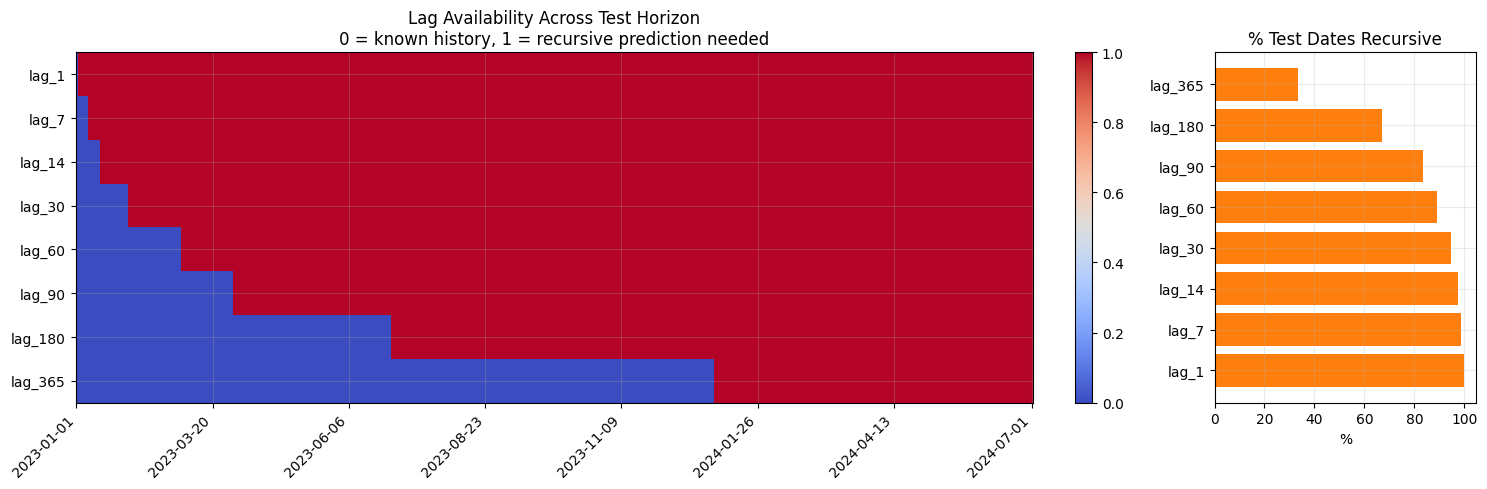

In [6]:
lag_days = [1, 7, 14, 30, 60, 90, 180, 365]
lag_summary = []
lag_matrix = []

for lag in lag_days:
    lagged_dates = test_dates - pd.Timedelta(days=lag)
    known_mask = lagged_dates < TEST_START
    recursive_mask = ~known_mask
    first_recursive = test_dates[recursive_mask.argmax()] if recursive_mask.any() else pd.NaT
    lag_summary.append({
        "lag_feature": f"revenue_lag_{lag}",
        "known_from_historical_actuals": int(known_mask.sum()),
        "requires_recursive_predictions": int(recursive_mask.sum()),
        "first_recursive_dependency_date": first_recursive,
        "pct_test_horizon_recursive": recursive_mask.mean(),
    })
    lag_matrix.append(np.where(known_mask, 0, 1))

lag_summary_df = pd.DataFrame(lag_summary)
display(lag_summary_df)

lag_matrix_arr = np.array(lag_matrix)
fig, axes = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={"width_ratios": [4, 1]})
im = axes[0].imshow(lag_matrix_arr, aspect="auto", cmap="coolwarm", interpolation="nearest")
axes[0].set_yticks(range(len(lag_days)))
axes[0].set_yticklabels([f"lag_{l}" for l in lag_days])
tick_positions = np.linspace(0, len(test_dates) - 1, 8, dtype=int)
axes[0].set_xticks(tick_positions)
axes[0].set_xticklabels(test_dates[tick_positions].strftime("%Y-%m-%d"), rotation=45, ha="right")
axes[0].set_title("Lag Availability Across Test Horizon\n0 = known history, 1 = recursive prediction needed")
plt.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

axes[1].barh([f"lag_{l}" for l in lag_days], lag_summary_df["pct_test_horizon_recursive"] * 100, color="tab:orange")
axes[1].set_title("% Test Dates Recursive")
axes[1].set_xlabel("%")
plt.tight_layout()
plt.show()

## 7. Rolling Feature Availability Analysis

Assume shifted rolling target features and classify whether each test date is fully known, partially recursive, or mostly/fully recursive.

,rolling_feature,fully_known_test_dates,partially_recursive_test_dates,mostly_fully_recursive_test_dates,first_date_affected_by_recursive_dependency
0,revenue_roll_mean_7_shifted,1,3,544,2023-01-02
1,revenue_roll_mean_14_shifted,1,6,541,2023-01-02
2,revenue_roll_mean_30_shifted,1,14,533,2023-01-02
3,revenue_roll_mean_90_shifted,1,44,503,2023-01-02
4,revenue_roll_mean_180_shifted,1,89,458,2023-01-02
5,revenue_roll_mean_365_shifted,1,182,365,2023-01-02


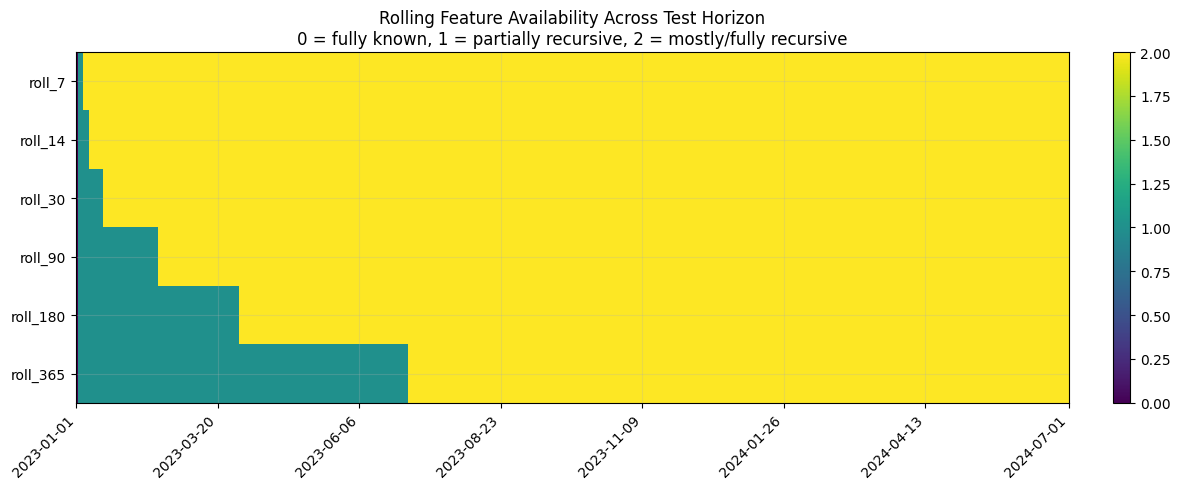

In [7]:
rolling_windows = [7, 14, 30, 90, 180, 365]
rolling_summary = []
rolling_matrix = []

for window in rolling_windows:
    recursive_days_needed = np.minimum((test_dates - TEST_START).days, window)
    status = np.where(
        recursive_days_needed == 0, 0,
        np.where(recursive_days_needed < (window / 2), 1, 2)
    )
    first_recursive = test_dates[(recursive_days_needed > 0).argmax()] if (recursive_days_needed > 0).any() else pd.NaT
    rolling_summary.append({
        "rolling_feature": f"revenue_roll_mean_{window}_shifted",
        "fully_known_test_dates": int((status == 0).sum()),
        "partially_recursive_test_dates": int((status == 1).sum()),
        "mostly_fully_recursive_test_dates": int((status == 2).sum()),
        "first_date_affected_by_recursive_dependency": first_recursive,
    })
    rolling_matrix.append(status)

rolling_summary_df = pd.DataFrame(rolling_summary)
display(rolling_summary_df)

rolling_matrix_arr = np.array(rolling_matrix)
fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(rolling_matrix_arr, aspect="auto", cmap="viridis", interpolation="nearest")
ax.set_yticks(range(len(rolling_windows)))
ax.set_yticklabels([f"roll_{w}" for w in rolling_windows])
tick_positions = np.linspace(0, len(test_dates) - 1, 8, dtype=int)
ax.set_xticks(tick_positions)
ax.set_xticklabels(test_dates[tick_positions].strftime("%Y-%m-%d"), rotation=45, ha="right")
ax.set_title("Rolling Feature Availability Across Test Horizon\n0 = fully known, 1 = partially recursive, 2 = mostly/fully recursive")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## 8. Recursive Forecasting Risk Analysis

Quantify how recursive dependency depth grows through the horizon and why a long recursive chain can accumulate error.

,date,days_into_test,recursive_dependency_depth
0,2023-01-01,0,0
1,2023-01-02,1,1
2,2023-01-03,2,2
3,2023-01-04,3,3
4,2023-01-05,4,4
5,2023-01-06,5,5
6,2023-01-07,6,6
7,2023-01-08,7,7
8,2023-01-09,8,8
9,2023-01-10,9,9


,date,days_into_test,recursive_dependency_depth
533,2024-06-17,533,365
534,2024-06-18,534,365
535,2024-06-19,535,365
536,2024-06-20,536,365
537,2024-06-21,537,365
538,2024-06-22,538,365
539,2024-06-23,539,365
540,2024-06-24,540,365
541,2024-06-25,541,365
542,2024-06-26,542,365


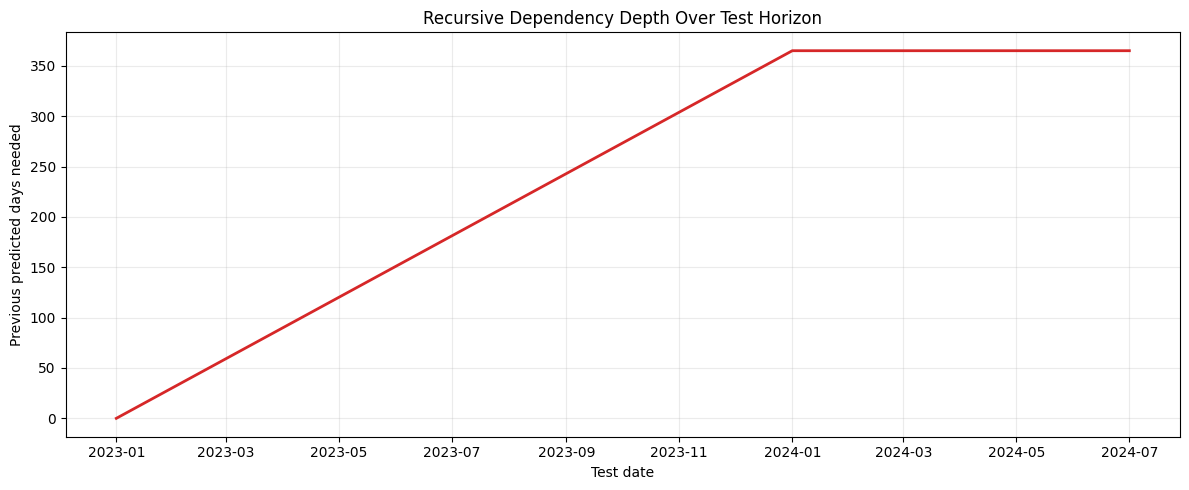

Recursive forecasting design reminder:
- Day 1 can use training-history target lags.
- Later test dates increasingly depend on earlier predictions for target-derived features.
- With rolling windows up to 365 days, recursive dependence grows to 365 predicted prior days.
- This makes pure recursive forecasting more vulnerable to cumulative error over a long horizon.


In [8]:
max_dependency_window = max(rolling_windows)
recursive_depth = pd.DataFrame({"date": test_dates})
recursive_depth["days_into_test"] = (recursive_depth["date"] - TEST_START).dt.days
recursive_depth["recursive_dependency_depth"] = np.minimum(recursive_depth["days_into_test"], max_dependency_window)

display(recursive_depth.head(15))
display(recursive_depth.tail(15))

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(recursive_depth["date"], recursive_depth["recursive_dependency_depth"], color="tab:red", lw=2)
ax.set_title("Recursive Dependency Depth Over Test Horizon")
ax.set_xlabel("Test date")
ax.set_ylabel("Previous predicted days needed")
plt.tight_layout()
plt.show()

print("Recursive forecasting design reminder:")
print("- Day 1 can use training-history target lags.")
print("- Later test dates increasingly depend on earlier predictions for target-derived features.")
print(f"- With rolling windows up to {max_dependency_window} days, recursive dependence grows to {max_dependency_window} predicted prior days.")
print("- This makes pure recursive forecasting more vulnerable to cumulative error over a long horizon.")

## 9. Direct Forecasting Strategy Analysis

Direct forecasting avoids feeding actual unknown test Revenue back into target-derived features. It is safer over long horizons when future exogenous features are known or can be forecast separately.

In [9]:
direct_strategy = pd.DataFrame([
    {
        "strategy": "Direct forecasting",
        "how_it_works": "Train horizon-aware models or one model with horizon features without using actual future target values.",
        "safe_feature_types": "Calendar, known future promo calendar if available, static training aggregates, historical lags up to test start only.",
        "strengths": "No recursive target leakage; avoids long error chains.",
        "limitations": "Can require more modeling complexity; harder to carry short-run autoregressive feedback."
    }
])
display(direct_strategy)

,strategy,how_it_works,safe_feature_types,strengths,limitations
0,Direct forecasting,Train horizon-aware models or one model with h...,"Calendar, known future promo calendar if avail...",No recursive target leakage; avoids long error...,Can require more modeling complexity; harder t...


## 10. Hybrid Forecasting Strategy Analysis

Hybrid forecasting combines safer long-horizon structure with limited autoregressive feedback where it genuinely helps and can be validated.

In [10]:
hybrid_strategy = pd.DataFrame([
    {
        "strategy": "Hybrid forecasting",
        "how_it_works": "Use direct calendar/exogenous structure for the full horizon and apply recursive target feedback cautiously for short-run dynamics or component forecasts.",
        "candidate_design": "Direct model with calendar features; separate forecasts for order count and AOV; optional short-horizon recursive lags validated carefully.",
        "strengths": "Balances stability and autoregressive signal; better fit for long horizons than pure recursion.",
        "limitations": "More moving parts; requires disciplined validation."
    },
    {
        "strategy": "Recursive forecasting",
        "how_it_works": "Predict day by day and feed earlier predictions back into target lags and rolling features.",
        "candidate_design": "Single autoregressive model iterated 548 times.",
        "strengths": "Simple training setup; natural autoregressive structure.",
        "limitations": "Long error chain; many lag/rolling features become prediction-driven quickly."
    }
])
display(hybrid_strategy)

,strategy,how_it_works,candidate_design,strengths,limitations
0,Hybrid forecasting,Use direct calendar/exogenous structure for th...,Direct model with calendar features; separate ...,Balances stability and autoregressive signal; ...,More moving parts; requires disciplined valida...
1,Recursive forecasting,Predict day by day and feed earlier prediction...,Single autoregressive model iterated 548 times.,Simple training setup; natural autoregressive ...,Long error chain; many lag/rolling features be...


## 11. Exogenous Feature Availability Classification

Classify which feature groups are safe across the test horizon, which need separate forecasting, and which are unsafe without leakage.

In [11]:
traffic_end = pd.NaT
if web_traffic is not None and traffic_cols.get("date"):
    traffic_end = pd.to_datetime(web_traffic[traffic_cols["date"]], errors="coerce").max()

promo_end = pd.NaT
promo_start = pd.NaT
if promotions is not None and promo_cols.get("start_date") and promo_cols.get("end_date"):
    promo_start = pd.to_datetime(promotions[promo_cols["start_date"]], errors="coerce").min()
    promo_end = pd.to_datetime(promotions[promo_cols["end_date"]], errors="coerce").max()

inventory_end = pd.NaT
if inventory is not None and inventory_cols.get("snapshot_date"):
    inventory_end = pd.to_datetime(inventory[inventory_cols["snapshot_date"]], errors="coerce").max()

feature_availability = pd.DataFrame([
    {
        "feature_group": "Calendar features",
        "examples": "day_of_week, month, quarter, holidays, month_end",
        "available_for_test_without_leakage": "Yes",
        "condition_for_safe_use": "Known from the date itself.",
        "recommended_treatment": "Use directly for all test dates.",
    },
    {
        "feature_group": "Revenue lags / rolling",
        "examples": "revenue_lag_7, revenue_roll_mean_30",
        "available_for_test_without_leakage": "Partly",
        "condition_for_safe_use": "Only historical values before 2023-01-01 are known; later test dates require recursive predictions.",
        "recommended_treatment": "Use cautiously; prefer direct or hybrid design for long horizons.",
    },
    {
        "feature_group": "Order count / AOV",
        "examples": "order_count_lag, AOV_lag, component forecasts",
        "available_for_test_without_leakage": "Partly",
        "condition_for_safe_use": "Actual future values are unknown; safe only as historical lags or separate forecasts.",
        "recommended_treatment": "Forecast separately or use lagged historical aggregates only.",
    },
    {
        "feature_group": "Traffic",
        "examples": "sessions, page_views, sessions_lag_7",
        "available_for_test_without_leakage": "No for actual future traffic",
        "condition_for_safe_use": f"Actual traffic history ends at {traffic_end.date() if pd.notna(traffic_end) else 'unknown'}; future actual traffic is unavailable.",
        "recommended_treatment": "Use only lagged historical traffic or forecast traffic separately.",
    },
    {
        "feature_group": "Promotions",
        "examples": "has_promo, active_promo_count",
        "available_for_test_without_leakage": "Only if future promo calendar is known",
        "condition_for_safe_use": f"Available promo dates in file run from {promo_start.date() if pd.notna(promo_start) else 'unknown'} to {promo_end.date() if pd.notna(promo_end) else 'unknown'}.",
        "recommended_treatment": "Use directly only if a valid future promo calendar exists for the test horizon.",
    },
    {
        "feature_group": "Inventory / stockout",
        "examples": "stockout_rate, fill_rate, days_of_supply",
        "available_for_test_without_leakage": "No for actual future inventory state",
        "condition_for_safe_use": f"Inventory history in file ends at {inventory_end.date() if pd.notna(inventory_end) else 'unknown'}.",
        "recommended_treatment": "Use lagged training aggregates or planned inventory if genuinely known in advance.",
    },
    {
        "feature_group": "Returns / refunds",
        "examples": "return_rate_lag, refund_amount_lag",
        "available_for_test_without_leakage": "No for actual future returns",
        "condition_for_safe_use": "Returns are recorded after sales happen.",
        "recommended_treatment": "Use only lagged historical aggregates, mainly for net-Revenue modeling.",
    },
    {
        "feature_group": "Reviews / ratings",
        "examples": "avg_rating_lag, review_count_lag",
        "available_for_test_without_leakage": "No for actual future reviews",
        "condition_for_safe_use": "Future reviews are not known before the sale period.",
        "recommended_treatment": "Use lagged historical review aggregates only.",
    },
    {
        "feature_group": "Geography / category / customer mix",
        "examples": "top_region_share, category_mix, customer_mix",
        "available_for_test_without_leakage": "Partly",
        "condition_for_safe_use": "Static training aggregates are safe; future realized mix is not.",
        "recommended_treatment": "Use static or lagged historical summaries, not future realized mix.",
    },
])
display(feature_availability)

,feature_group,examples,available_for_test_without_leakage,condition_for_safe_use,recommended_treatment
0,Calendar features,"day_of_week, month, quarter, holidays, month_end",Yes,Known from the date itself.,Use directly for all test dates.
1,Revenue lags / rolling,"revenue_lag_7, revenue_roll_mean_30",Partly,Only historical values before 2023-01-01 are k...,Use cautiously; prefer direct or hybrid design...
2,Order count / AOV,"order_count_lag, AOV_lag, component forecasts",Partly,Actual future values are unknown; safe only as...,Forecast separately or use lagged historical a...
3,Traffic,"sessions, page_views, sessions_lag_7",No for actual future traffic,Actual traffic history ends at 2022-12-31; fut...,Use only lagged historical traffic or forecast...
4,Promotions,"has_promo, active_promo_count",Only if future promo calendar is known,Available promo dates in file run from 2013-01...,Use directly only if a valid future promo cale...
5,Inventory / stockout,"stockout_rate, fill_rate, days_of_supply",No for actual future inventory state,Inventory history in file ends at 2022-12-31.,Use lagged training aggregates or planned inve...
6,Returns / refunds,"return_rate_lag, refund_amount_lag",No for actual future returns,Returns are recorded after sales happen.,"Use only lagged historical aggregates, mainly ..."
7,Reviews / ratings,"avg_rating_lag, review_count_lag",No for actual future reviews,Future reviews are not known before the sale p...,Use lagged historical review aggregates only.
8,Geography / category / customer mix,"top_region_share, category_mix, customer_mix",Partly,Static training aggregates are safe; future re...,"Use static or lagged historical summaries, not..."


## 12. Recommended Modeling Decision

Compare direct, recursive, and hybrid strategies against this specific 548-day horizon and recommend a practical design.

In [12]:
strategy_comparison = pd.DataFrame([
    {
        "strategy": "Direct",
        "safe_for_548d_horizon": "High",
        "target_lag_leakage_risk": "Low",
        "error_accumulation_risk": "Low",
        "practical_note": "Best when relying on calendar features, separately forecasted components, and known future exogenous features."
    },
    {
        "strategy": "Recursive",
        "safe_for_548d_horizon": "Low",
        "target_lag_leakage_risk": "Manageable only with strict simulation",
        "error_accumulation_risk": "High",
        "practical_note": "Becomes prediction-driven quickly; many lags and all rolling features require recursive values after the first test days."
    },
    {
        "strategy": "Hybrid",
        "safe_for_548d_horizon": "Highest practical balance",
        "target_lag_leakage_risk": "Low to moderate",
        "error_accumulation_risk": "Moderate",
        "practical_note": "Recommended: direct long-horizon backbone plus carefully validated short-run autoregressive or component forecasts."
    },
])
display(strategy_comparison)

decision_lines = []
decision_lines.append(f"Test horizon length: {len(test_dates)} daily predictions.")
if not train_test_boundary.empty:
    decision_lines.append(
        f"Training Revenue history reaches {train_test_boundary['last_known_Revenue_date'].iloc[0].date()} with continuous boundary history = {bool(train_test_boundary['continuous_history_to_boundary'].iloc[0])}."
    )
decision_lines.append("Short lags such as lag_1, lag_7, and lag_14 are known only for the early part of the test horizon; later test dates require recursive values.")
decision_lines.append("All shifted rolling target features are fully known only on the first test day and become recursive immediately after that.")
decision_lines.append("Pure recursive forecasting is risky here because the horizon is long and recursive dependency depth grows to hundreds of prior predicted days.")
decision_lines.append("Recommended strategy: hybrid, with direct forecasting as the main long-horizon design and recursive target lags used cautiously only when validated.")
decision_lines.append("Safe exogenous features: calendar features, static training aggregates, and only future promo indicators if a valid future promo calendar is genuinely known.")
decision_lines.append("Traffic, order_count, AOV, inventory, returns, and reviews should be forecast separately or converted to lagged historical aggregates rather than treated as known future values.")
print("\n".join(decision_lines))

,strategy,safe_for_548d_horizon,target_lag_leakage_risk,error_accumulation_risk,practical_note
0,Direct,High,Low,Low,"Best when relying on calendar features, separa..."
1,Recursive,Low,Manageable only with strict simulation,High,Becomes prediction-driven quickly; many lags a...
2,Hybrid,Highest practical balance,Low to moderate,Moderate,Recommended: direct long-horizon backbone plus...


Test horizon length: 548 daily predictions.
Training Revenue history reaches 2022-12-31 with continuous boundary history = True.
Short lags such as lag_1, lag_7, and lag_14 are known only for the early part of the test horizon; later test dates require recursive values.
All shifted rolling target features are fully known only on the first test day and become recursive immediately after that.
Pure recursive forecasting is risky here because the horizon is long and recursive dependency depth grows to hundreds of prior predicted days.
Recommended strategy: hybrid, with direct forecasting as the main long-horizon design and recursive target lags used cautiously only when validated.
Safe exogenous features: calendar features, static training aggregates, and only future promo indicators if a valid future promo calendar is genuinely known.
Traffic, order_count, AOV, inventory, returns, and reviews should be forecast separately or converted to lagged historical aggregates rather than treated a

## 13. Key Observations and Warnings

Summarize horizon length, boundary quality, lag/rolling availability, recursive risk, safe exogenous features, and the final strategy recommendation.

In [13]:
summary_lines = ["KEY OBSERVATIONS AND WARNINGS"]
summary_lines.append(f"- Test horizon length: {len(test_dates)} days from {TEST_START.date()} to {TEST_END.date()}.")

if not train_test_boundary.empty:
    summary_lines.append(
        f"- Training Revenue history is {'continuous' if bool(train_test_boundary['continuous_history_to_boundary'].iloc[0]) else 'not fully continuous'} up to the test start; last known Revenue date is {train_test_boundary['last_known_Revenue_date'].iloc[0].date()}."
    )
else:
    summary_lines.append("- Training Revenue boundary continuity could not be verified because Revenue history was unavailable.")

if not lag_summary_df.empty:
    early_known = lag_summary_df.loc[lag_summary_df["known_from_historical_actuals"] > 0, "lag_feature"].tolist()
    recursive_needed = lag_summary_df.loc[lag_summary_df["requires_recursive_predictions"] > 0, "lag_feature"].tolist()
    summary_lines.append("- Lag features fully known for early test dates: " + ", ".join(early_known) + ".")
    summary_lines.append("- Lag features that require recursive predictions for part of the horizon: " + ", ".join(recursive_needed) + ".")

if not rolling_summary_df.empty:
    roll_recursive = rolling_summary_df["rolling_feature"].tolist()
    summary_lines.append("- Rolling features require recursive predictions almost immediately after the test start: " + ", ".join(roll_recursive) + ".")

summary_lines.append("- Pure recursive forecasting may accumulate error because the 548-day horizon creates a long chain of target-derived predictions.")
summary_lines.append("- Recommended strategy: hybrid, with direct forecasting as the main structure and recursive target feedback used cautiously for short-term dynamics only after validation.")
summary_lines.append("- Safe test-period exogenous features: calendar features, static training aggregates, and future promo features only if a real future promo calendar is known in advance.")
summary_lines.append("- Features that must be forecasted separately or converted to lagged historical aggregates: traffic, order count, AOV, inventory/stockout, returns/refunds, reviews/ratings, and realized future geography/category mix.")
summary_lines.append("- Final warning: never use actual test-period Revenue, actual future traffic, actual future orders/AOV, actual future returns, or unknown future inventory values when building test features.")
print("\n".join(summary_lines))

KEY OBSERVATIONS AND WARNINGS
- Test horizon length: 548 days from 2023-01-01 to 2024-07-01.
- Training Revenue history is continuous up to the test start; last known Revenue date is 2022-12-31.
- Lag features fully known for early test dates: revenue_lag_1, revenue_lag_7, revenue_lag_14, revenue_lag_30, revenue_lag_60, revenue_lag_90, revenue_lag_180, revenue_lag_365.
- Lag features that require recursive predictions for part of the horizon: revenue_lag_1, revenue_lag_7, revenue_lag_14, revenue_lag_30, revenue_lag_60, revenue_lag_90, revenue_lag_180, revenue_lag_365.
- Rolling features require recursive predictions almost immediately after the test start: revenue_roll_mean_7_shifted, revenue_roll_mean_14_shifted, revenue_roll_mean_30_shifted, revenue_roll_mean_90_shifted, revenue_roll_mean_180_shifted, revenue_roll_mean_365_shifted.
- Pure recursive forecasting may accumulate error because the 548-day horizon creates a long chain of target-derived predictions.
- Recommended strategy: 